In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv


### 1. Le Résidu ($e$)
Le résidu représente l'écart entre la valeur **réelle** et **la prédiction** du modèle pour une observation donnée $i$ :

$$e_i = y_i - \hat{y}_i$$


### 2. Mean Absolute Error (MAE)
La MAE est la moyenne des valeurs absolues des erreurs. Elle est **robuste** aux valeurs **aberrantes (outliers)** car elle ne lève pas l'erreur au carré.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Pourquoi on l'utilise : On privilégie la MAE lorsqu'on a besoin d'une métrique facile à communiquer aux décideurs métier (marketing, direction financière).

L'avantage : Elle nous donne une erreur moyenne dans l'unité réelle (ex: "On se trompe en moyenne de 10 000 €").

La particularité : Elle est robuste. Si on a quelques maisons aux prix extrêmes (outliers) très mal prédites, elles n'écraseront pas le score global.

On compare l'erreur MAE à **la moyenne** ou à **l'écart-type** de la variable cible.


### 3. Mean Squared Error (MSE)
La MSE calcule la moyenne des carrés des erreurs. Elle pénalise fortement les grandes erreurs, ce qui est utile si l'on veut éviter les prédictions très éloignées de la réalité.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


### 4. Root Mean Squared Error (RMSE)
Le RMSE est la racine carrée de la MSE. Il permet d'exprimer l'erreur dans la même unité que la variable cible (ex: en euros pour un prix).

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Pourquoi on utilise les RMSE / MSE: On utilise la MSE lors de l'optimisation mathématique du modèle. La RMSE est préférée pour le rapport final de performance technique.

L'avantage : Le passage au carré "punit" les grosses erreurs.

La logique : Si on considère qu'une erreur de 50 000 € est dix fois pire qu'une erreur de 5 000 €, alors on choisit la RMSE. Elle force le modèle à être plus conservateur et à éviter les énormes plantages.

Si on voit que la RMSE est beaucoup plus grande que la MAE (ex: MAE=10, RMSE=50), on sait qu'on a des outliers que le modèle n'arrive pas du tout à gérer.


### 5. Coefficient de Détermination ($R^2$)
Le $R^2$ indique la proportion de la variance de la variable dépendante qui est expliquée par le modèle. Ilcalcule combien d'incertitude ton modèle a "effacé" par rapport à la simple moyenne. Il se base sur la Somme des Carrés des Résidus ($SS_{res}$) et la Somme Totale des Carrés ($SS_{tot}$). 

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

*Où $\bar{y}$ est la moyenne des valeurs réelles.*

Pourquoi on l'utilise : On s'en sert pour donner une note globale de fiabilité au modèle, indépendamment de l'unité de mesure.

L'avantage : C'est un pourcentage d'explication de la variance.

La logique : On compare l'erreur de notre modèle à l'erreur d'une simple ligne moyenne. Si on obtient 0.80, on peut dire qu'on a expliqué 80% de la variation des prix.

Le coefficient de détermination $R^2$ n'a pas de valeur universelle. Son interprétation dépend de la complexité du domaine d'étude :

* **Performance Excellente ($R^2 > 0.9$)** : 
Objectif visé en **sciences dures** (physique, ingénierie). On considère que le modèle capture la quasi-totalité des lois physiques.
$$R^2 \in [0.9, 1.0]$$

* **Performance Très Bonne ($0.7 < R^2 < 0.9$)** : 
Excellent score pour les **sciences appliquées** (immobilier, finance, météo). Le modèle explique une grande partie de la variance.
$$R^2 \in [0.7, 0.9]$$

* **Performance Correcte ($0.4 < R^2 < 0.7$)** : 
Score souvent jugé satisfaisant en **sciences humaines ou sociales**. Prédire le comportement humain est complexe.
$$R^2 \in [0.4, 0.7]$$

* **Performance Faible ($R^2 < 0.3$)** : 
Le modèle est considéré comme peu prédictif. Les variables choisies n'ont probablement pas de lien direct avec la cible.
$$R^2 < 0.3$$

### 6. Adjusted $R^2$
Contrairement au $R^2$ classique, **le $R^2$ ajusté** prend en compte le nombre de variables prédictrices ($p$) par rapport à la taille de l'échantillon ($n$), évitant ainsi de surévaluer la performance d'un modèle trop complexe.

$$R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$

Pourquoi on l'utilise : On doit l'utiliser dès qu'on commence à ajouter beaucoup de colonnes (caractéristiques) à notre modèle.

Le piège : Le R² classique augmente toujours, même si on ajoute des données inutiles.

La solution : Le R² ajusté nous protège contre le overfitting. Si on ajoute une variable et que le R² ajusté baisse, on sait qu'on doit retirer cette variable.

# Application:

on choisit dataset */kaggle/input/datasets/fedesoriano/the-boston-houseprice-data* car :

**Complexité réelle :** Il y a 79 variables (le quartier, le type de toit, la qualité du chauffage, etc.). C'est parfait pour tester notre R2 ajusté.

**Nettoyage de données :** Il y a beaucoup de valeurs manquantes. On va devoir décider comment les traiter avant de calculer nos métriques.

**Évaluation par le RMSE :** La compétition Kaggle utilise officiellement le Log-RMSE pour classer les participants.

In [23]:
#les métriques faits main

def residu_fm(y_true,y_pred):
    return y_true-y_pred

def MAE_fm(y_true,y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    errors = np.abs(y_true - y_pred)
    return np.mean(errors)

def MSE_fm(y_true,y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    errors = (y_true-y_pred)**2
    return np.mean(errors)

def RMSE_fm(y_true,y_pred):
    return np.sqrt(MSE_fm(y_true,y_pred))

def R2_fm(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_bar = np.mean(y_true)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_bar)**2)
    return 1 - (ss_res / ss_tot)

def R2_ajusté_fm(y_true, y_pred, p):
    #p : nombre de variables indépendantes (features) utilisées dans le modèle
    y_true = np.array(y_true)
    n = len(y_true) # Nombre d'observations
    r2 = R2_fm(y_true, y_pred)
    adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
    return adjusted_r2

Métrique        | manuek-l             | Sklearn (Official)
------------------------------------------------------------
MAE             | 2.0395               | 2.0395         
RMSE            | 2.8110               | 2.8110         
R²              | 0.8923               | 0.8923         
R² Ajusté       | 0.8763               | 0.8763         


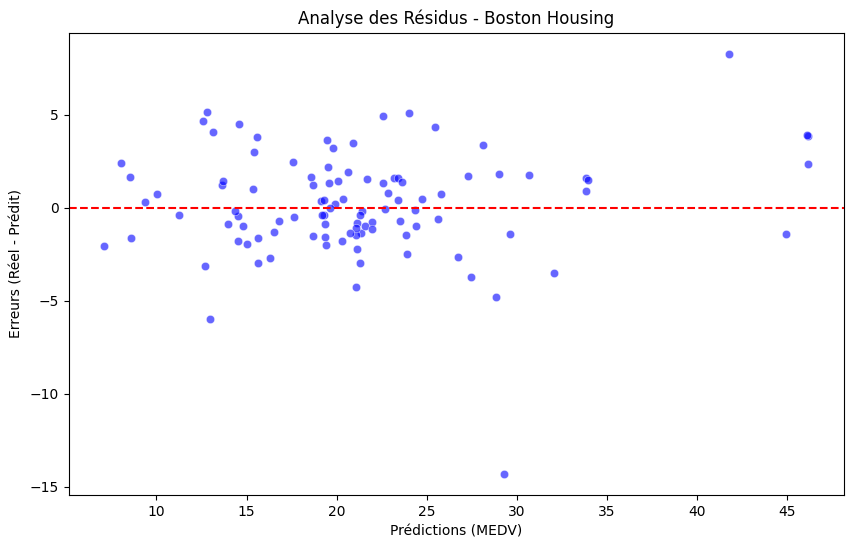

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv')

#Séparation Dynamique : y est la dernière colonne, X est tout le reste
y = df.iloc[:, -1]  # Prend 'MEDV' (la dernière colonne)
X = df.iloc[:, :-1] # Prend toutes les colonnes SAUF la dernière

#remplissage des vides par la médiane
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Paramètres pour l'Adjusted R²
n = len(y_test)
p = X_test.shape[1]

mae_m  = MAE_fm(y_test, y_pred)
rmse_m = RMSE_fm(y_test, y_pred)
r2_m   = R2_fm(y_test, y_pred)
adj_r2_m = R2_ajusté_fm(y_test, y_pred, p)

sk_mae  = mean_absolute_error(y_test, y_pred)
sk_mse  = mean_squared_error(y_test, y_pred)
sk_rmse = np.sqrt(sk_mse)
sk_r2   = r2_score(y_test, y_pred)

sk_adj_r2 = 1 - ((1 - sk_r2) * (n - 1)) / (n - p - 1)

print(f"{'Métrique':<15} | {'manuek-l':<20} | {'Sklearn (Official)':<15}")
print("-" * 60)
print(f"{'MAE':<15} | {mae_m:<20.4f} | {sk_mae:<15.4f}")
print(f"{'RMSE':<15} | {rmse_m:<20.4f} | {sk_rmse:<15.4f}")
print(f"{'R²':<15} | {r2_m:<20.4f} | {sk_r2:<15.4f}")
print(f"{'R² Ajusté':<15} | {adj_r2_m:<20.4f} | {sk_adj_r2:<15.4f}")

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Analyse des Résidus - Boston Housing')
plt.xlabel('Prédictions (MEDV)')
plt.ylabel('Erreurs (Réel - Prédit)')
plt.show()
